## We have another question for you: When do our users usually complete the labs: in the night, morning, afternoon, or evening? How has this changed over time?

Create a graph like this one:
Analyze only the users, not the admins.
The font size and fig size are still the same.
Night is from 0:00:00 to 03:59:59, morning is from 04:00:00 to 09:59:59, afternoon is from 10:00:00 to 16:59:59, and evening is from 17:00:00 to 23:59:59.
Choose a palette you really enjoy. You do not have to replicate it from the graph above.
At the end of your Jupyter notebook, create a Markdown cell and insert the following questions:
When do our users usually commit to the labs: in the night, morning, afternoon, or evening? The answer is the two most common periods.
Which day has:
the most number of commits?
and at the same time, is the number of commits higher in the evening than in the afternoon?

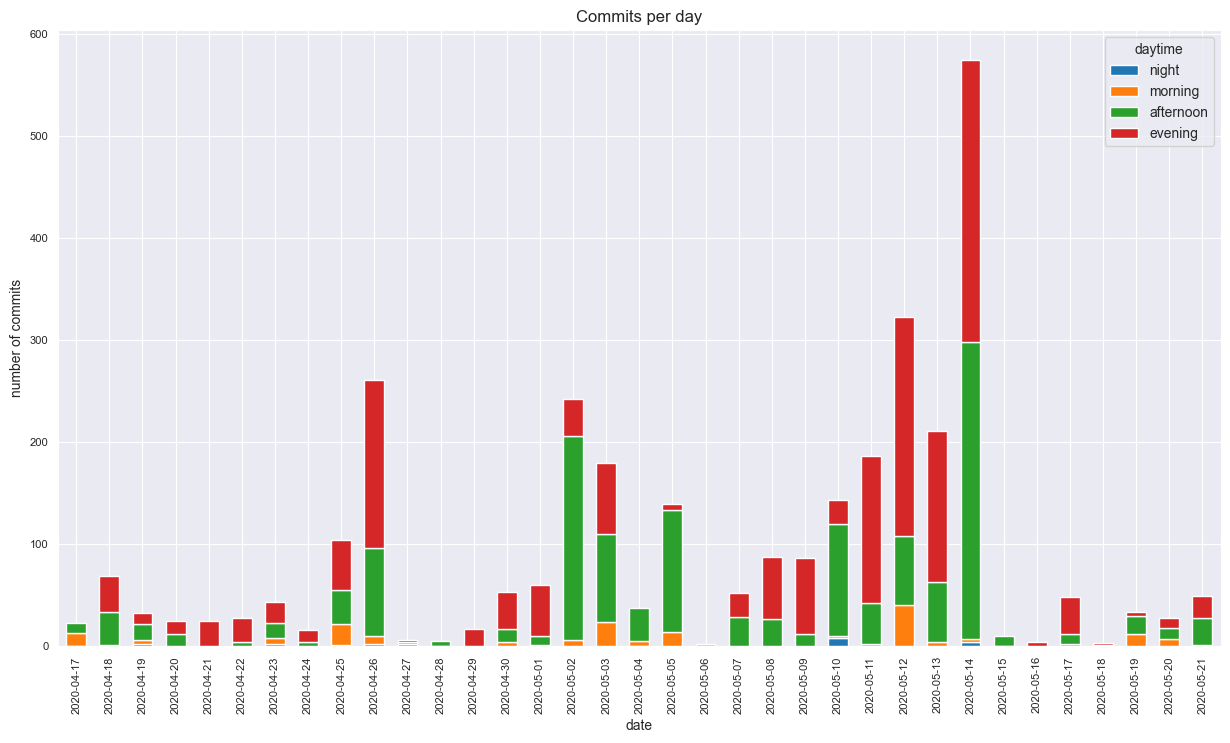

In [1]:
import pandas as pd
import sqlite3
conn = sqlite3.connect('../data/checking-logs.sqlite')
query = """
    SELECT 
    timestamp  FROM checker
    WHERE uid LIKE "user_%"
"""
work = pd.read_sql_query(query, conn)
work['timestamp'] = pd.to_datetime(work['timestamp'])
work['hour'] = work['timestamp'].dt.hour
dayTimes = ['night','morning','afternoon','evening']
dayTimings= [0,4,10,17,24]
work['daytime']= pd.cut(
    work['hour'],
    bins=dayTimings,
    labels=dayTimes,
    right=False
)
work['date'] = work['timestamp'].dt.date
daily = (
    work
    .groupby(['date', 'daytime'], observed=True)
    .size()
    .unstack('daytime')      
    .fillna(0)
)

daily.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 8),
    width=0.6,
    title='Commits per day',
    fontsize=8,
    rot=90,
    legend="daytime",
    xlabel="date",
    ylabel='number of commits'
)

conn.close()


## Когда наши пользователи обычно заходят в лаборатории: ночью, утром, днем или вечером? 

Ответ: днем и вечером

## В какой день было:

Наибольшее количество коммитов?
И в то же время, количество коммитов выше вечером, чем днем?

Ответ: 2020-05-14 